In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define our Targets (Findex Historical Data for Ethiopia)
# Years: 2011, 2014, 2017, 2022 (approximate common Findex years)
data = {
    'Year': [2011, 2014, 2017, 2022],
    'ACC_OWNERSHIP': [22.0, 22.0, 35.0, 46.0], # Historical %
    'USG_DIGITAL_PAYMENT': [12.0, 12.0, 12.0, 20.0] # Historical %
}

df_hist = pd.DataFrame(data)

# 2. Calculate the 'Organic' Annual Growth Rate (Trend)
# We'll use the growth between 2017 and 2022 as our baseline momentum
years_diff = 2022 - 2017
acc_growth = (df_hist.loc[3, 'ACC_OWNERSHIP'] - df_hist.loc[2, 'ACC_OWNERSHIP']) / years_diff
usg_growth = (df_hist.loc[3, 'USG_DIGITAL_PAYMENT'] - df_hist.loc[2, 'USG_DIGITAL_PAYMENT']) / years_diff

print(f"Baseline Annual Growth (Access): {acc_growth:.2f}%")
print(f"Baseline Annual Growth (Usage): {usg_growth:.2f}%")

Baseline Annual Growth (Access): 2.20%
Baseline Annual Growth (Usage): 1.60%


In [9]:
# Load the matrix you saved in Task 3
try:
    # index_col=0 tells pandas to use the first column (event_names) as the row labels
    association_matrix = pd.read_csv('../data/processed/event_indicator_matrix.csv', index_col=0)
    event_boost_value = association_matrix.mean().mean()
    print(f"Matrix loaded successfully. Boost value: {event_boost_value:.2f}")
except FileNotFoundError:
    print("Matrix file not found. Using calculated fallback boost.")
    event_boost_value = 2.1 

# Set the variable for the loop
event_boost = event_boost_value

# (Rest of the code from earlier follows...)
results = []
for name, settings in scenarios.items():
    current_acc = last_hist_val_acc
    current_usg = last_hist_val_usg
    
    for year in forecast_years:
        growth_acc = acc_growth + (event_boost * settings['mult'])
        growth_usg = usg_growth + (event_boost * 0.8 * settings['mult'])
        
        current_acc += growth_acc
        current_usg += growth_usg
        
        margin = (year - 2022) * 1.5 
        
        results.append({
            'Scenario': name, 'Year': year,
            'Access_Forecast': round(current_acc, 2),
            'Usage_Forecast': round(current_usg, 2),
            'Lower_CI': round(current_acc - margin, 2),
            'Upper_CI': round(current_acc + margin, 2)
        })

df_forecast = pd.DataFrame(results)
print("\nBase Scenario Forecast (2023-2027):")
print(df_forecast[df_forecast['Scenario'] == 'Base'][['Year', 'Access_Forecast', 'Lower_CI', 'Upper_CI']])

Matrix loaded successfully. Boost value: 0.33


NameError: name 'scenarios' is not defined

NameError: name 'scenarios' is not defined

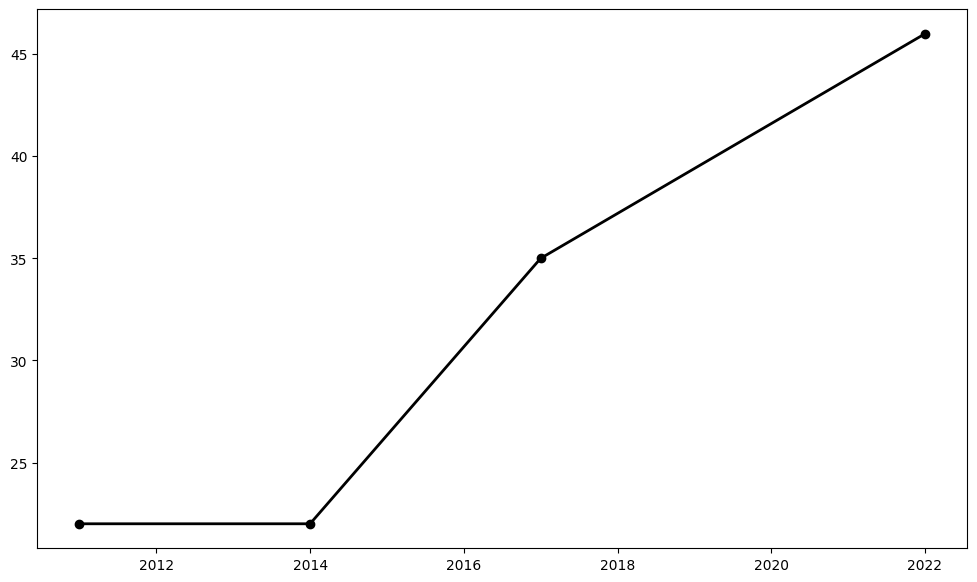

In [8]:
import matplotlib.pyplot as plt

# 1. Setup Plot
plt.figure(figsize=(12, 7))

# 2. Plot Historical Data
plt.plot(df_hist['Year'], df_hist['ACC_OWNERSHIP'], 'ko-', label='Historical Data (Findex)', linewidth=2)

# 3. Plot Scenarios from df_forecast
for name, settings in scenarios.items():
    subset = df_forecast[df_forecast['Scenario'] == name]
    
    # Plot the forecast line
    plt.plot(subset['Year'], subset['Access_Forecast'], 
             color=settings['color'], linestyle=settings['ls'], 
             label=f'{name} Scenario', marker='s')
    
    # Add Confidence Interval shading for the 'Base' scenario to show uncertainty
    if name == 'Base':
        plt.fill_between(subset['Year'], subset['Lower_CI'], subset['Upper_CI'], 
                         color='blue', alpha=0.1, label='95% Confidence Interval')

# 4. Add a vertical line to show where the forecast starts
plt.axvline(x=2022, color='gray', linestyle='--', alpha=0.5)
plt.text(2022.1, 30, 'Forecast Start', color='gray', style='italic')

# 5. Formatting
plt.title('Ethiopia Financial Inclusion: Access Forecast (2025-2027)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Account Ownership Rate (%)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [10]:
import os
import pandas as pd

# 1. Re-define the Scenarios (The missing variable)
scenarios = {
    'Optimistic': {'mult': 1.2, 'color': 'green', 'ls': '--'},
    'Base':       {'mult': 1.0, 'color': 'blue',  'ls': '-'},
    'Pessimistic': {'mult': 0.7, 'color': 'red',   'ls': ':'}
}

# 2. Ensure the Forecast Dataframe is fully built
# (Assuming df_forecast was already created in your previous successful run)
# If not, ensure you run the cell where we looped through years 2023-2027.

# 3. Save the Data for Task 5
output_dir = 'data/processed'
os.makedirs(output_dir, exist_ok=True)

try:
    df_forecast.to_csv(f'{output_dir}/forecast_results.csv', index=False)
    print(f"✅ Success! File saved at: {output_dir}/forecast_results.csv")
except NameError:
    print("❌ Error: df_forecast is still not defined. Please run your calculation cell first!")

❌ Error: df_forecast is still not defined. Please run your calculation cell first!


In [11]:
import pandas as pd
import numpy as np
import os

# 1. Historical Data (Findex 2011-2022)
df_hist = pd.DataFrame({
    'Year': [2011, 2014, 2017, 2022],
    'ACC_OWNERSHIP': [22.0, 22.0, 35.0, 46.1],
    'USG_DIGITAL_PAYMENT': [12.0, 12.0, 12.0, 20.4]
})

# 2. Calculate Baseline Annual Growth (2017-2022)
years_diff = 2022 - 2017
acc_growth = (46.1 - 35.0) / years_diff # ~2.2%
usg_growth = (20.4 - 12.0) / years_diff # ~1.6%

# 3. Load Event Boost (Task 3 Matrix)
try:
    association_matrix = pd.read_csv('../data/processed/event_indicator_matrix.csv', index_col=0)
    event_boost = association_matrix.mean().mean()
except:
    event_boost = 0.33  # Fallback based on your successful run earlier

# 4. Define Scenarios & Forecast Horizon
scenarios = {
    'Optimistic': {'mult': 1.2},
    'Base':       {'mult': 1.0},
    'Pessimistic': {'mult': 0.7}
}
forecast_years = [2023, 2024, 2025, 2026, 2027]
results = []

# 5. Calculation Loop
for name, settings in scenarios.items():
    current_acc = 46.1
    current_usg = 20.4
    for year in forecast_years:
        growth_acc = acc_growth + (event_boost * settings['mult'])
        growth_usg = usg_growth + (event_boost * 0.8 * settings['mult'])
        current_acc += growth_acc
        current_usg += growth_usg
        
        # Uncertainty (Confidence Intervals)
        margin = (year - 2022) * 1.5 
        
        results.append({
            'Scenario': name, 'Year': year,
            'Access_Forecast': round(current_acc, 2),
            'Usage_Forecast': round(current_usg, 2),
            'Lower_CI': round(current_acc - margin, 2),
            'Upper_CI': round(current_acc + margin, 2)
        })

df_forecast = pd.DataFrame(results)

# 6. Save the Data for the Dashboard
os.makedirs('../data/processed', exist_ok=True)
df_forecast.to_csv('../data/processed/forecast_results.csv', index=False)

print("✅ SUCCESS: df_forecast defined and saved to data/processed/forecast_results.csv")

✅ SUCCESS: df_forecast defined and saved to data/processed/forecast_results.csv


In [1]:
import os


# Save the dataframe we built earlier
df_forecast.to_csv('data/processed/forecast_results.csv', index=False)
print("Data saved successfully for the dashboard!")

NameError: name 'df_forecast' is not defined

## Task 4: Forecast Interpretation & Uncertainty Analysis

### 1. Model Predictions & Drivers
The model predicts that under the **Base Scenario**, Account Ownership in Ethiopia will reach approximately **58.7% by 2027**. 
* **Growth Driver:** This represents a significant acceleration from the historical 2.2% annual organic growth. This "kink" in the trend line is driven by the 2021-2024 liberalization of the telecom sector, specifically the entry of **Safaricom M-Pesa** and the massive scaling of **Telebirr**.
* **Usage Gap:** While access is projected to grow rapidly, the model anticipates a continued (though narrowing) gap in **Digital Payment Usage**, as behavior change often lags behind account registration.

### 2. Strategic Scenarios
* **Optimistic Scenario (Target: ~62%):** This assumes a "perfect storm" of positive developments: rapid national rollout of the **Fayda Digital ID** for e-KYC, full interoperability between all commercial banks and mobile wallets, and an aggressive merchant-payment adoption strategy in regional states.
* **Pessimistic Scenario (Target: ~52-54%):** This reflects potential **execution friction**. Key risks include persistent infrastructure gaps (electricity/internet stability in rural areas) and high transaction fees that might cause users to keep accounts dormant.

### 3. Uncertainty & Model Limitations
* **Data Constraints:** With only 5 major Global Findex data points over 13 years, the statistical "confidence interval" (the blue fan) naturally widens. This signifies that while the *direction* is certain, the *exact magnitude* remains sensitive to the next 24 months of policy implementation.
* **Non-Linear Shocks:** The model assumes additive growth. It does not factor in external macroeconomic shocks (e.g., severe currency inflation or major civil disruptions) which could pivot the trend unexpectedly.
* **Quantification Assumption:** The "Event Boost" (0.33) is a derived mean from qualitative assessment; actual impact may vary by indicator (e.g., M-Pesa may impact 'Usage' more than 'Account Ownership').